# 03B - Baseline CNN with Augmentation and Mild Targeted Oversampling

This experiment keeps the custom baseline CNN and on-the-fly augmentation from `03A`, then adds mild targeted oversampling on the training dataframe only.

No class weights are used. The goal is to improve minority/weak class exposure without the aggressive loss distortion observed in the full class-weight experiment.

Compare against:

- `02_baseline_cnn.ipynb`: plain baseline, accuracy about 0.7555, macro F1 about 0.7008
- `03A_baseline_cnn_augmentation_only.ipynb`: augmentation only, accuracy about 0.7502, macro F1 about 0.6984
- previous full class weights run: accuracy about 0.6776, macro F1 about 0.6347


## 1. Project setup


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(f"Could not find src/ from current directory: {NOTEBOOK_DIR}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: d:\UWE\3rd Year\2nd semester\advanced_ai\ai_system


## 2. Imports and configuration


In [2]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay

from src.config import (
    CLASS_NAMES_PATH,
    CM_DIR,
    FIGURES_DIR,
    IMAGE_SIZE,
    MODELS_DIR,
    NUM_CLASSES,
    RANDOM_SEED,
    GROUPED_SPLITS_DIR,
)

# Use grouped source-image splits to avoid offline-augmentation leakage.
SPLITS_DIR = GROUPED_SPLITS_DIR
from src.data.augmentations import build_training_augmentation
from src.data.dataloaders import make_dataset_from_dataframe
from src.data.prepare_dataset import targeted_oversample_dataframe
from src.models.baseline_cnn import build_baseline_cnn
from src.train.evaluate import evaluate_model
from src.train.train import compile_model, train_model

tf.keras.utils.set_random_seed(RANDOM_SEED)

EXPERIMENT_NAME = "baseline_cnn_aug_oversampled"
TARGET_MIN_COUNT = 500
EPOCHS = 12
LEARNING_RATE = 1e-3

EXPERIMENT_MODELS_DIR = MODELS_DIR / "experiments"
EXPERIMENT_MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Experiment:", EXPERIMENT_NAME)
print("Target minimum train count:", TARGET_MIN_COUNT)


TensorFlow: 2.21.0
GPUs: []
Experiment: baseline_cnn_aug_oversampled
Target minimum train count: 500


## 3. Load split files and class names


In [3]:
train_csv = SPLITS_DIR / "train.csv"
val_csv = SPLITS_DIR / "val.csv"
test_csv = SPLITS_DIR / "test.csv"

for path in [train_csv, val_csv, test_csv, CLASS_NAMES_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}. Run 01_eda.ipynb first.")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = json.load(f)

class_to_index = {name: idx for idx, name in enumerate(class_names)}

for split_df in [train_df, val_df, test_df]:
    if "class_index" not in split_df.columns:
        split_df["class_index"] = split_df["class_name"].map(class_to_index)

print("Original train/val/test:", len(train_df), len(val_df), len(test_df))
print("Classes:", len(class_names))
assert len(class_names) == NUM_CLASSES


Original train/val/test: 20493 4392 4392
Classes: 28


## 4. Mild targeted oversampling

Only training rows are oversampled. Validation and test remain untouched.

Classes below `TARGET_MIN_COUNT` are sampled with replacement until they reach the target count. Larger classes are not downsampled.


In [4]:
original_counts = train_df["class_name"].value_counts().reindex(class_names)
train_oversampled_df = targeted_oversample_dataframe(
    train_df,
    target_min_count=TARGET_MIN_COUNT,
    class_column="class_name",
    random_state=RANDOM_SEED,
)

oversampled_counts = train_oversampled_df["class_name"].value_counts().reindex(class_names)
oversampling_summary = pd.DataFrame({
    "class_name": class_names,
    "original_train_count": original_counts.values,
    "oversampled_train_count": oversampled_counts.values,
})
oversampling_summary["added_rows"] = (
    oversampling_summary["oversampled_train_count"]
    - oversampling_summary["original_train_count"]
)
oversampling_summary["oversampled_ratio"] = (
    oversampling_summary["oversampled_train_count"]
    / oversampling_summary["original_train_count"]
).round(2)

display(oversampling_summary.sort_values("added_rows", ascending=False))
print("Original train rows:", len(train_df))
print("Oversampled train rows:", len(train_oversampled_df))
print("Added rows:", len(train_oversampled_df) - len(train_df))


,class_name,original_train_count,oversampled_train_count,added_rows,oversampled_ratio
11,Grape__Rotten,140,500,360,3.57
10,Grape__Healthy,140,500,360,3.57
13,Guava__Rotten,140,500,360,3.57
12,Guava__Healthy,140,500,360,3.57
15,Jujube__Rotten,140,500,360,3.57
14,Jujube__Healthy,140,500,360,3.57
20,Pomegranate__Healthy,140,500,360,3.57
21,Pomegranate__Rotten,140,500,360,3.57
7,Carrot__Rotten,405,500,95,1.23
23,Potato__Rotten,409,500,91,1.22


Original train rows: 20493
Oversampled train rows: 24174
Added rows: 3681


## 5. Build TensorFlow datasets

The training dataset uses the oversampled dataframe. Validation and test use the original split dataframes.


In [5]:
train_ds = make_dataset_from_dataframe(train_oversampled_df, class_to_index, training=True)
val_ds = make_dataset_from_dataframe(val_df, class_to_index, training=False)
test_ds = make_dataset_from_dataframe(test_df, class_to_index, training=False)

for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)
    print("Label batch:", labels.shape)


Image batch: (32, 224, 224, 3)
Label batch: (32,)


## 6. Build and train augmented oversampled baseline


In [6]:
checkpoint_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_best.keras"

augmentation = build_training_augmentation()
model = build_baseline_cnn(num_classes=NUM_CLASSES, augmentation=augmentation)
model = compile_model(model, learning_rate=LEARNING_RATE)
model.summary()

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=EPOCHS,
    checkpoint_path=checkpoint_path,
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,860 (378.36 KB)

 Trainable params: 96,860 (378.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
756/756 ━━━━━━━━━━━━━━━━━━━━ 242s 318ms/step - accuracy: 0.2590 - loss: 2.4740 - val_accuracy: 0.4670 - val_loss: 1.8091 - learning_rate: 0.0010
Epoch 2/12
756/756 ━━━━━━━━━━━━━━━━━━━━ 234s 308ms/step - accuracy: 0.4757 - loss: 1.7735 - val_accuracy: 0.5351 - val_loss: 1.5751 - learning_rate: 0.0010
Epoch 3/12
756/756 ━━━━━━━━━━━━━━━━━━━━ 230s 303ms/step - accuracy: 0.5472 - loss: 1.5435 - val_accuracy: 0.6075 - val_loss: 1.3674 - learning_rate: 0.0010
Epoch 4/12
756/756 ━━━━━━━━━━━━━━━━━━━━ 229s 302ms/step - accuracy: 0.5972 - loss: 1.3955 - val_accuracy: 0.6236 - val_loss: 1.2756 - learning_rate: 0.0010
Epoch 5/12
756/756 ━━━━━━━━━━━━━━━━━━━━ 230s 303ms/step - accuracy: 0.6271 - loss: 1.2869 - val_accuracy: 0.6400 - val_loss: 1.2112 - learning_rate: 0.0010
Epoch 6/12
756/756 ━━━━━━━━━━━━━━━━━━━━ 231s 305ms/step - accuracy: 0.6518 - loss: 1.2050 - val_accuracy: 0.6949 - val_loss: 1.0717 - learning_rate: 0.0010
Epoch 7/12
756/756 ━━━━━━━━━━━━━━━━━━━━ 228s 301ms/step - accura

## 7. Training curves


,accuracy,loss,val_accuracy,val_loss,learning_rate
7,0.693141,1.068197,0.714025,0.982490,0.001
8,0.704021,1.017192,0.715619,0.973585,0.001
9,0.718582,0.963901,0.729281,0.941494,0.001
10,0.732109,0.933104,0.721311,0.941477,0.001
11,0.740175,0.883445,0.752049,0.869931,0.001


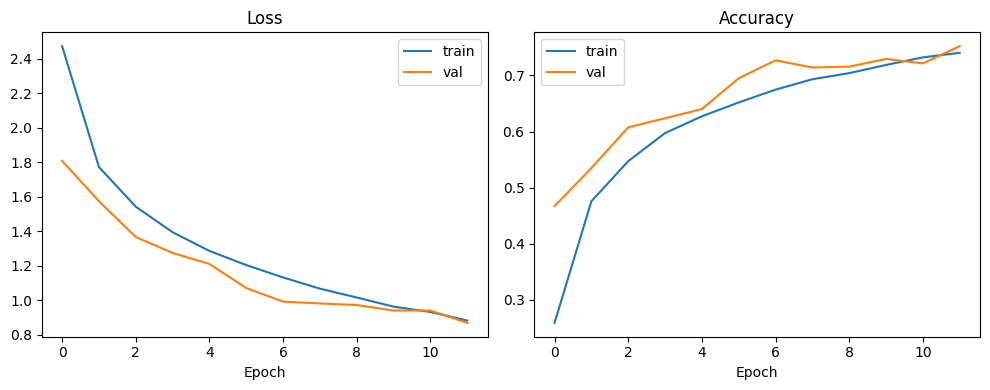

In [7]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train")
plt.plot(history_df["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train")
plt.plot(history_df["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
curves_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()


## 8. Evaluate on test set


In [8]:
results = evaluate_model(model, test_ds, class_names)
report = results["classification_report"]
cm = results["confusion_matrix"]

report_df = pd.DataFrame(report).transpose()
display(report_df)

accuracy = float(report["accuracy"])
macro_f1 = float(report["macro avg"]["f1-score"])
weighted_f1 = float(report["weighted avg"]["f1-score"])

print("Test accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))


,precision,recall,f1-score,support
Apple__Healthy,0.870370,0.772603,0.818578,365.000000
Apple__Rotten,0.762791,0.747153,0.754891,439.000000
Banana__Healthy,0.837545,0.773333,0.804159,300.000000
Banana__Rotten,0.855556,0.918854,0.886076,419.000000
Bellpepper__Healthy,0.870588,0.804348,0.836158,92.000000
Bellpepper__Rotten,0.444444,0.269663,0.335664,89.000000
Carrot__Healthy,0.772727,0.731183,0.751381,93.000000
Carrot__Rotten,0.515152,0.586207,0.548387,87.000000
Cucumber__Healthy,0.563380,0.879121,0.686695,91.000000
Cucumber__Rotten,0.686869,0.764045,0.723404,89.000000


Test accuracy: 0.7561
Macro F1: 0.7217
Weighted F1: 0.7569


## 9. Focus on weak classes from the plain baseline


In [9]:
weak_classes_from_plain_baseline = [
    "Tomato__Rotten",
    "Bellpepper__Rotten",
    "Potato__Rotten",
    "Pomegranate__Rotten",
    "Carrot__Rotten",
]

available_weak_classes = [name for name in weak_classes_from_plain_baseline if name in report_df.index]
display(report_df.loc[available_weak_classes, ["precision", "recall", "f1-score", "support"]])


,precision,recall,f1-score,support
Tomato__Rotten,0.494505,0.500000,0.497238,90.0
Bellpepper__Rotten,0.444444,0.269663,0.335664,89.0
Potato__Rotten,0.415493,0.678161,0.515284,87.0
Pomegranate__Rotten,0.406780,0.800000,0.539326,30.0
Carrot__Rotten,0.515152,0.586207,0.548387,87.0


## 10. Optional comparison with previous experiment reports

This cell compares against saved reports if they exist locally.


In [10]:
comparison_paths = {
    "plain_baseline": FIGURES_DIR / "baseline_cnn_classification_report.csv",
    "aug_only": FIGURES_DIR / "baseline_cnn_aug_only_classification_report.csv",
}

rows = []
for name, path in comparison_paths.items():
    if path.exists():
        prev = pd.read_csv(path, index_col=0)
        rows.append({
            "experiment": name,
            "accuracy": float(prev.loc["accuracy", "precision"]),
            "macro_f1": float(prev.loc["macro avg", "f1-score"]),
            "weighted_f1": float(prev.loc["weighted avg", "f1-score"]),
        })

rows.append({
    "experiment": EXPERIMENT_NAME,
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
})

comparison_df = pd.DataFrame(rows)
display(comparison_df)


,experiment,accuracy,macro_f1,weighted_f1
0,plain_baseline,0.755464,0.700839,0.744463
1,aug_only,0.750228,0.698354,0.744730
2,baseline_cnn_aug_oversampled,0.756148,0.721686,0.756913


## 11. Confusion matrix


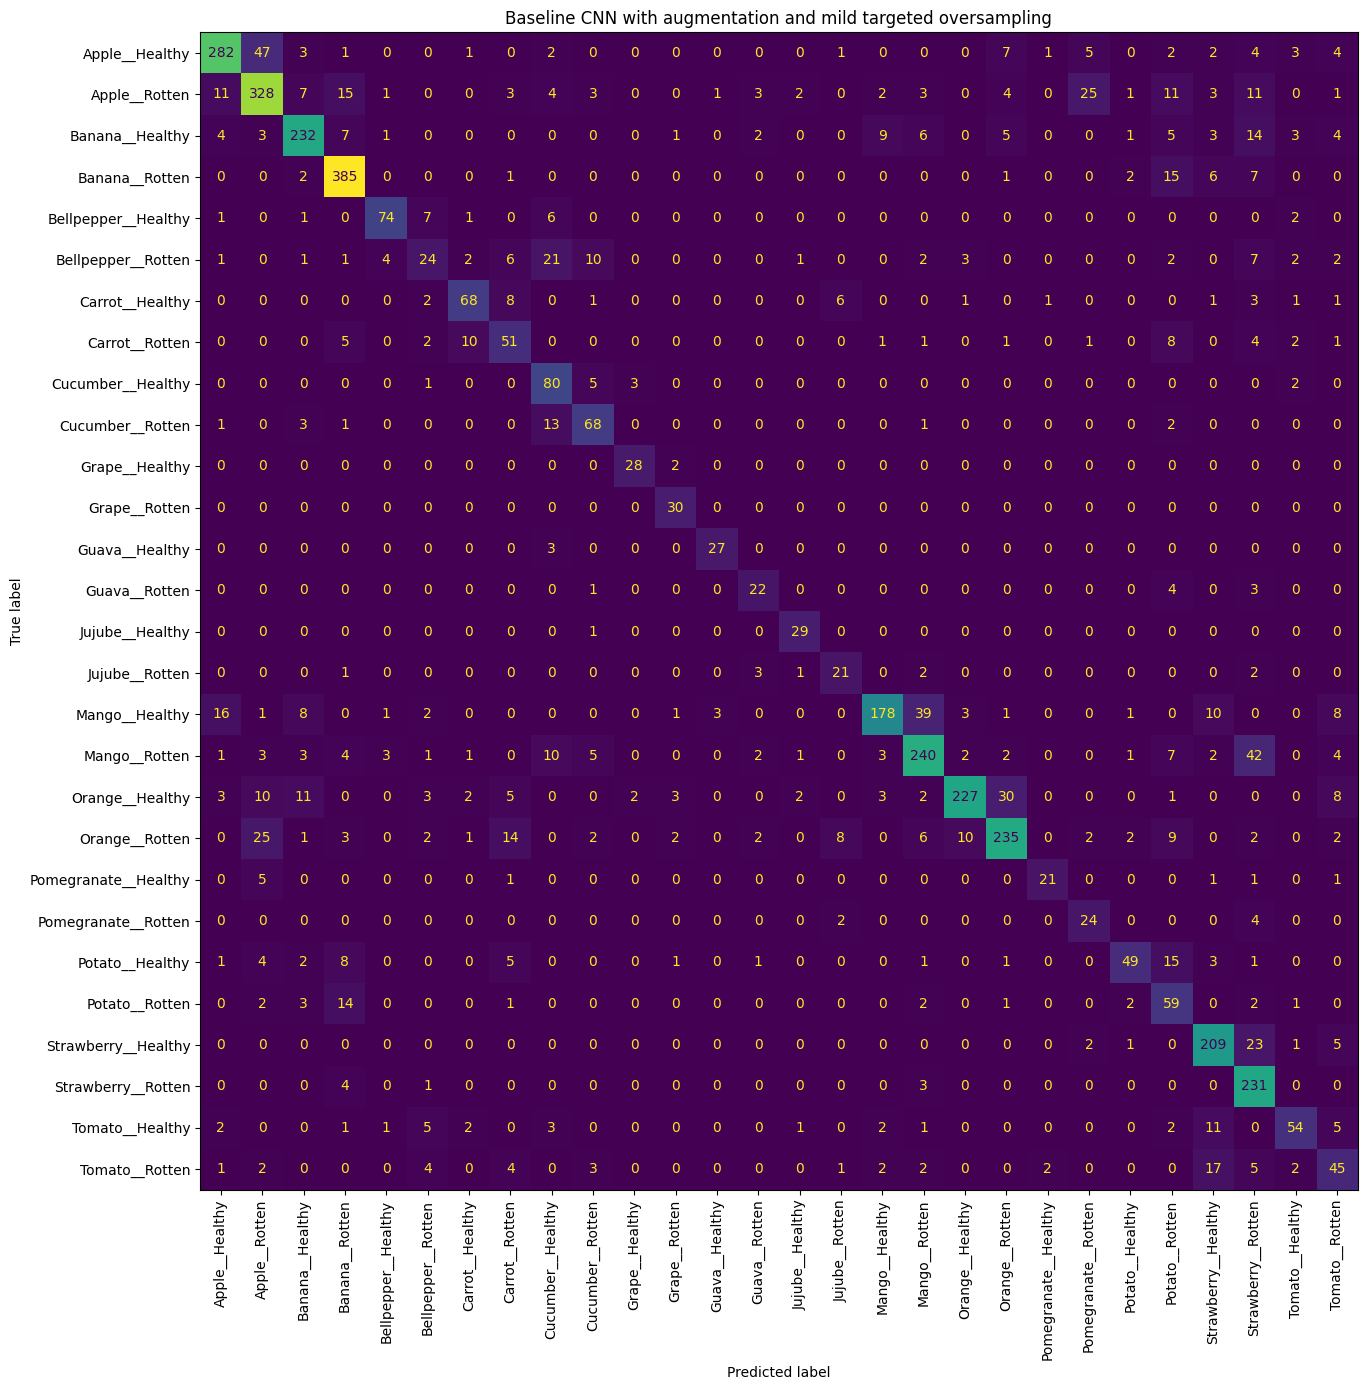

In [11]:
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Baseline CNN with augmentation and mild targeted oversampling")
plt.tight_layout()
cm_path = CM_DIR / f"{EXPERIMENT_NAME}_confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()


## 12. Save experiment artifacts

This notebook does not overwrite `models/best_model.keras`. That file should only be updated after comparing all candidate models.


In [12]:
model_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}.keras"
metadata_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_metadata.json"
report_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_classification_report.csv"
oversampling_summary_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_oversampling_summary.csv"

model.save(model_path)
report_df.to_csv(report_path)
oversampling_summary.to_csv(oversampling_summary_path, index=False)

metadata = {
    "model_name": EXPERIMENT_NAME,
    "base_model_family": "custom_baseline_cnn",
    "dataset": "muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten",
    "num_classes": NUM_CLASSES,
    "image_size": list(IMAGE_SIZE),
    "epochs_requested": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "augmentation": True,
    "class_weighting": None,
    "oversampling": {
        "enabled": True,
        "strategy": "targeted_min_count_with_replacement",
        "target_min_count": TARGET_MIN_COUNT,
        "original_train_rows": int(len(train_df)),
        "oversampled_train_rows": int(len(train_oversampled_df)),
    },
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "metrics": {
        "test_accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    },
    "artifacts": {
        "model": str(model_path),
        "checkpoint": str(checkpoint_path),
        "metadata": str(metadata_path),
        "classification_report": str(report_path),
        "oversampling_summary": str(oversampling_summary_path),
        "training_curves": str(curves_path),
        "confusion_matrix": str(cm_path),
    },
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved experiment model:", model_path)
print("Saved checkpoint:", checkpoint_path)
print("Saved metadata:", metadata_path)
print("Saved oversampling summary:", oversampling_summary_path)
print("Did not overwrite models/best_model.keras")


Saved experiment model: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\models\experiments\baseline_cnn_aug_oversampled.keras
Saved checkpoint: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\models\experiments\baseline_cnn_aug_oversampled_best.keras
Saved metadata: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\models\experiments\baseline_cnn_aug_oversampled_metadata.json
Saved oversampling summary: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\models\experiments\baseline_cnn_aug_oversampled_oversampling_summary.csv
Did not overwrite models/best_model.keras


## 13. Decision rule

This experiment is useful if it improves macro F1 or weak rotten-class F1 without a large accuracy drop.

If it improves the weak classes but still does not beat the plain baseline overall, keep the result as evidence that custom CNN capacity is the limiting factor and move to MobileNetV2 transfer learning.
